# Redo Question 2 using JAX
Sources: 

+ https://python.quantecon.org/ifp_discrete.html 
+ https://github.com/f0uriest/interpax


This was done to check the matlab code mostly

In [67]:
import quantecon as qe
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from typing import NamedTuple
from time import time
from interpax import interp1d

In [68]:
jax.config.update("jax_enable_x64", True)

In [69]:
class Model(NamedTuple):
    β: float              # Discount factor
    R: float              # Gross interest rate
    γ: float              # CRRA parameter
    a_grid: jnp.ndarray   # Asset grid
    y_grid: jnp.ndarray   # Income grid
    Q: jnp.ndarray        # Markov matrix for income

# modify to tauchen 
def create_consumption_model(
        R = 1.02,                    # Gross interest rate
        β = 0.96,                    # Discount factor
        γ = 1.5,                       # CRRA parameter
        σ = 0.2,                      # shock 
        a_min = 0.0,                # Min assets
        a_max = 50.0,                # Max assets
        a_size = 100,                # Grid size
        c = 2,                       # curvature
        ρ = 0.9, ν = 0.2, y_size = 5   # Income parameters
    ):
    """
    Creates an instance of the consumption-savings model.

    """
    a_grid = a_min + (a_max - a_min) * jnp.linspace(0, 1, a_size) ** c
    mc = qe.rouwenhorst(n = y_size, rho= ρ, sigma = σ)
    y_grid, Q = jnp.exp(mc.state_values), jax.device_put(mc.P)
    return Model(β, R, γ, a_grid, y_grid, Q)

In [70]:
@jax.jit
def B(v, model):
    """
    A vectorized version of the right-hand side of the Bellman equation
    (before maximization), which is a 3D array representing

        B(a, y, a′) = u(Ra + y - a′) + β Σ_y′ v(a′, y′) Q(y, y′)

    for all (a, y, a′).
    """

    # Unpack
    β, R, γ, a_grid, y_grid, Q = model
    a_size, y_size = len(a_grid), len(y_grid)

    # Compute current rewards r(a, y, ap) as array r[i, j, ip]
    a  = jnp.reshape(a_grid, (a_size, 1, 1))    # a[i]   ->  a[i, j, ip]
    y  = jnp.reshape(y_grid, (1, y_size, 1))    # z[j]   ->  z[i, j, ip]
    ap = jnp.reshape(a_grid, (1, 1, a_size))    # ap[ip] -> ap[i, j, ip]
    c = R * a + y - ap

    def interp_col(v_col):
        # v_col: (a_size,) — value function for one income state
        # returns interpolated values at all ap points: (a_size,)
        return interp1d(a_grid, v_col, ap, method="cubic")

    # v_interp[ip, jp] = cubic-spline estimate of v(a′[ip], y[jp])
    v_interp = jax.vmap(interp_col, in_axes=1, out_axes=1)(v)

    # Calculate continuation rewards at all combinations of (a, y, ap)
    v = jnp.reshape(v_interp, (1, 1, a_size, y_size))  # v[ip, jp] -> v[i, j, ip, jp]
    Q = jnp.reshape(Q, (1, y_size, 1, y_size))  # Q[j, jp]  -> Q[i, j, ip, jp]
    EV = jnp.sum(v * Q, axis=3)                 # sum over last index jp

    # Compute the right-hand side of the Bellman equation
    return jnp.where(c > 0, c**(1-γ)/(1-γ) + β * EV, -jnp.inf)

In [71]:
@jax.jit
def T(v, model):
    "The Bellman operator."
    return jnp.max(B(v, model), axis=2)

In [72]:
@jax.jit
def get_greedy(v, model):
    "Computes a v-greedy policy, returned as a set of indices."
    return jnp.argmax(B(v, model), axis=2)

In [73]:
def value_function_iteration_python(model, tol=1e-5, max_iter=10_000):
    """
    Implements VFI using successive approximation with a Python loop.
    """
    v = jnp.zeros((len(model.a_grid), len(model.y_grid)))
    error = tol + 1
    k = 0

    while error > tol and k < max_iter:
        v_new = T(v, model)
        error = jnp.max(jnp.abs(v_new - v))
        v = v_new
        k += 1

    return v, get_greedy(v, model)

In [74]:
@jax.jit
def value_function_iteration(model, tol=1e-4, max_iter=10_000):
    """
    Implements VFI using successive approximation.
    """
    def body_fun(k_v_err):
        k, v, error = k_v_err
        v_new = T(v, model)
        error = jnp.max(jnp.abs(v_new - v))
        
        return k + 1, v_new, error

    def cond_fun(k_v_err):
        k, v, error = k_v_err
        return jnp.logical_and(error > tol, k < max_iter)

    v_init = jnp.zeros((len(model.a_grid), len(model.y_grid)))
    k, v_star, error = jax.lax.while_loop(cond_fun, body_fun,
                                          (1, v_init, tol + 1))
    return v_star, get_greedy(v_star, model)

In [75]:
model = create_consumption_model()

/var/folders/r1/ygmywd652zq_jmsr6k782p_00000gn/T/ipykernel_29344/2227189196.py:26: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = qe.rouwenhorst(n = y_size, rho= ρ, sigma = σ)


In [76]:
print("Starting VFI using jax.lax.while_loop.")
start = time()
v_star_jax, σ_star_jax = value_function_iteration(model)
v_star_jax.block_until_ready()
jax_with_compile = time() - start
print(f"VFI completed in {jax_with_compile} seconds.")

Starting VFI using jax.lax.while_loop.


ValueError: x and f must be arrays of equal length

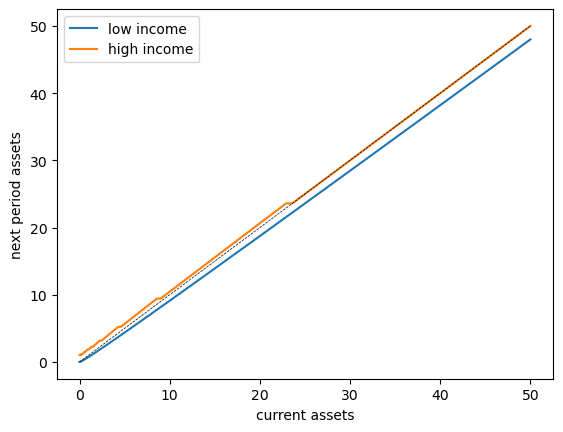

In [ ]:
fig, ax = plt.subplots()

# Plot asset accumulation for first and last income states
for j, label in zip([0, -1], ['low income', 'high income']):
    # Get next-period assets for each current asset level
    a_next = model.a_grid[σ_star_jax[:, j]]
    ax.plot(model.a_grid, a_next, label=label)

# Add 45-degree line
ax.plot(model.a_grid, model.a_grid, 'k--', linewidth=0.5)
ax.set(xlabel='current assets', ylabel='next period assets')
ax.legend()
plt.show()